# Experiment 1 — headline benchmark (LGD)

5-fold CV on the LGD datasets (loss-given-default regression on [0, 1]; tuned/HPO models). For every matrix metric — **R²**, **Pearson correlation** — the **same three views**: matrix, per-method bar (fold-level std), and an across-dataset box. The **rank by R²** (kept right after R²) gets the same three views. Then the **effect of HPO**, a **time analysis** (train + predict + HPO), and a summary. Foundation-model names are **red**. Figures → `figures/experiment1/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, metric_bars, metric_boxplots,
    rank_heatmap, method_ranking_bars, rank_boxplots,
    hpo_improvement_bars, compute_time_bars, compute_time_boxplot,
    runtime_performance_scatter, foundation_vs_baseline_size_trend,
    foundation_vs_baseline_scatter, calibration_bias_table,
    selected_method_calibration_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/lgd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\lgd


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode='HPO')
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode=None)
print(f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets')

27 methods x 7 datasets


## 1. R² — explained variance

Matrix · per-method bar (fold-level std) · across-dataset box.

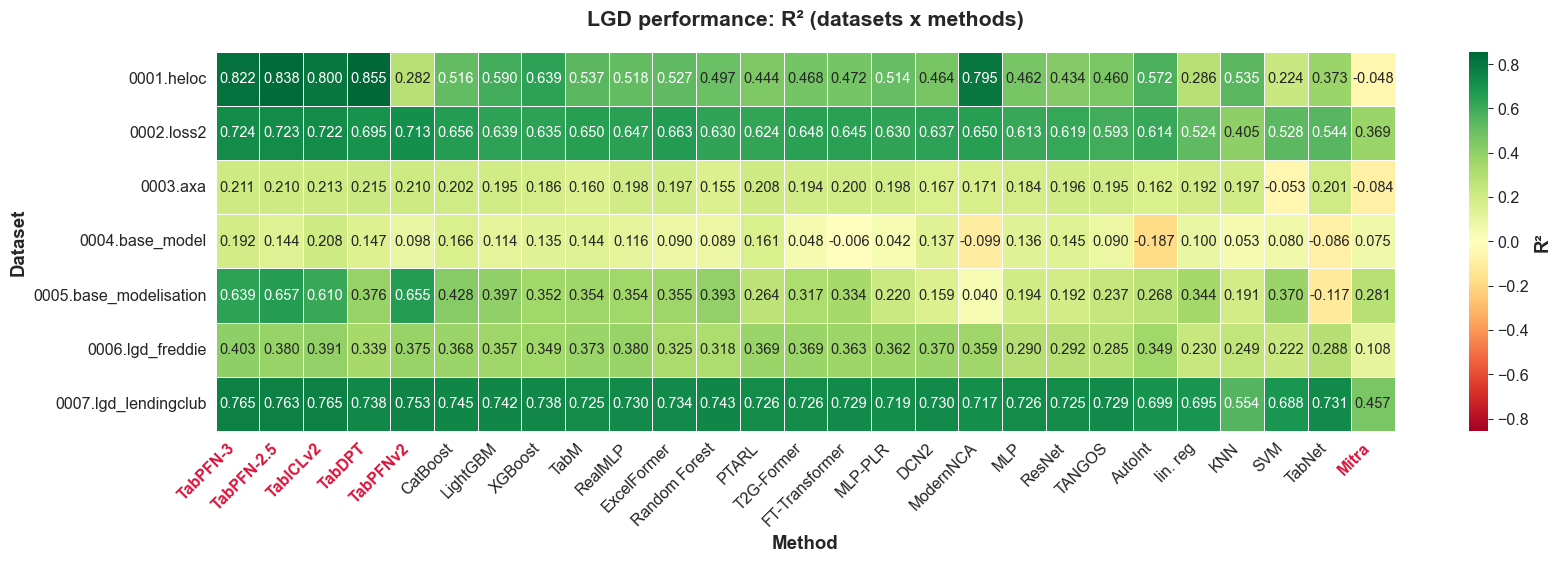

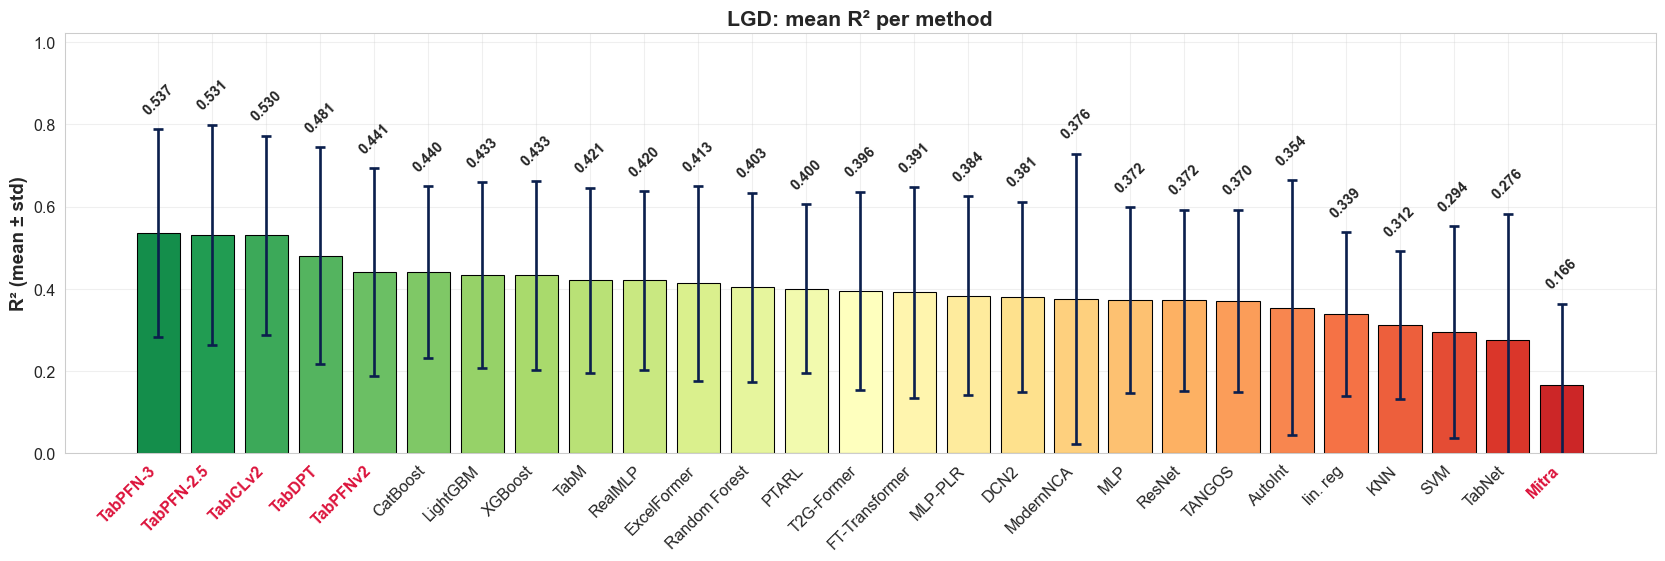

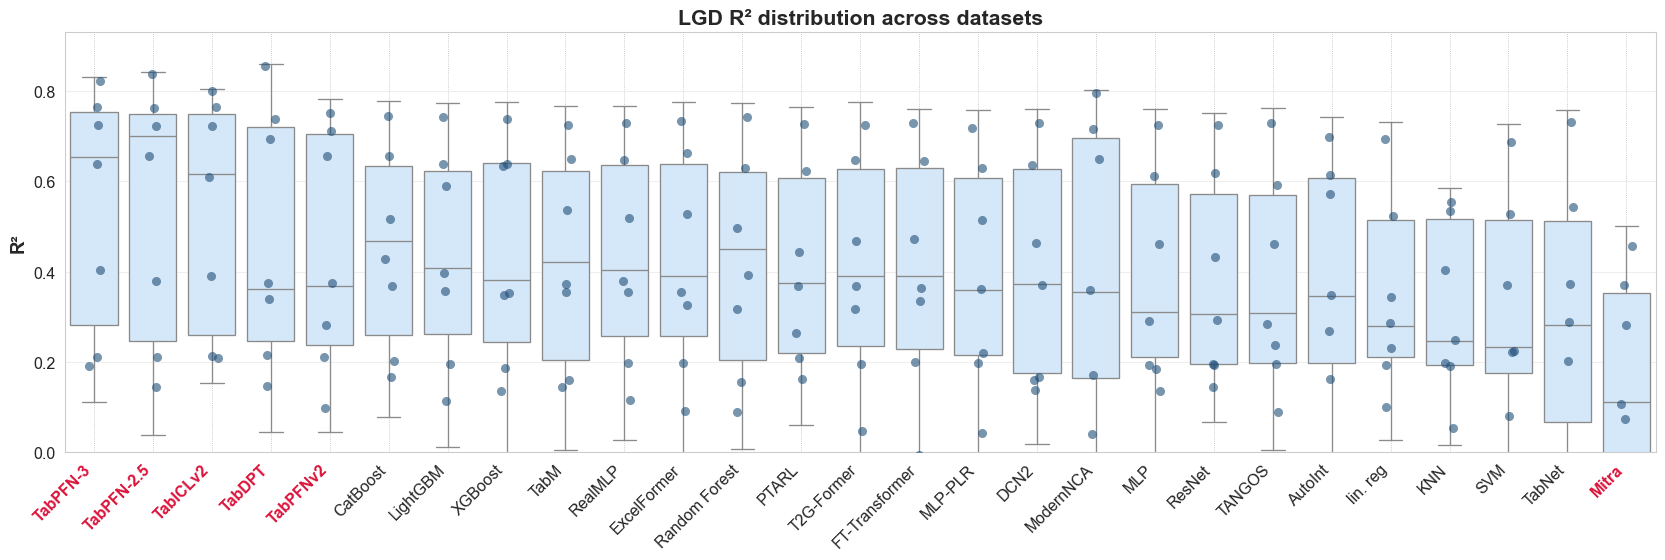

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_r2.pdf')

In [3]:
performance_heatmap(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)

## 2. Rank by R² (1 = best on that dataset)

The per-dataset ranking that underlies the R² table — kept right next to it. Matrix · mean-rank bar · rank box.

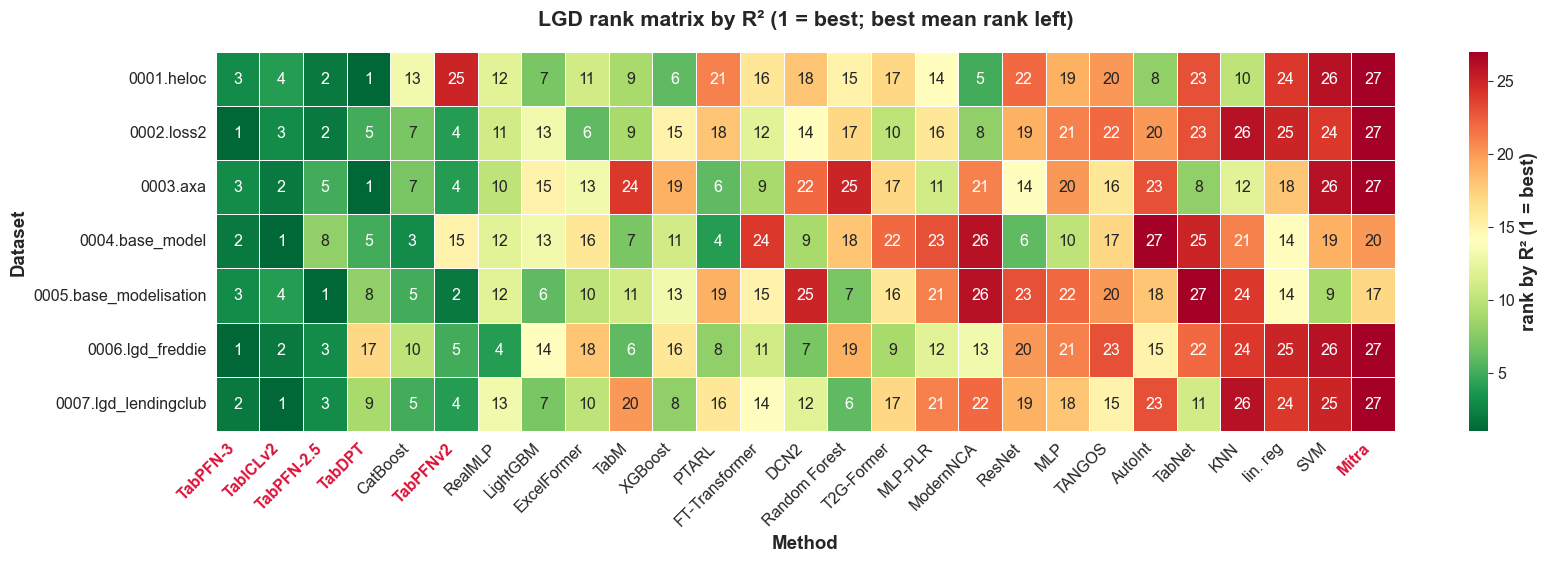

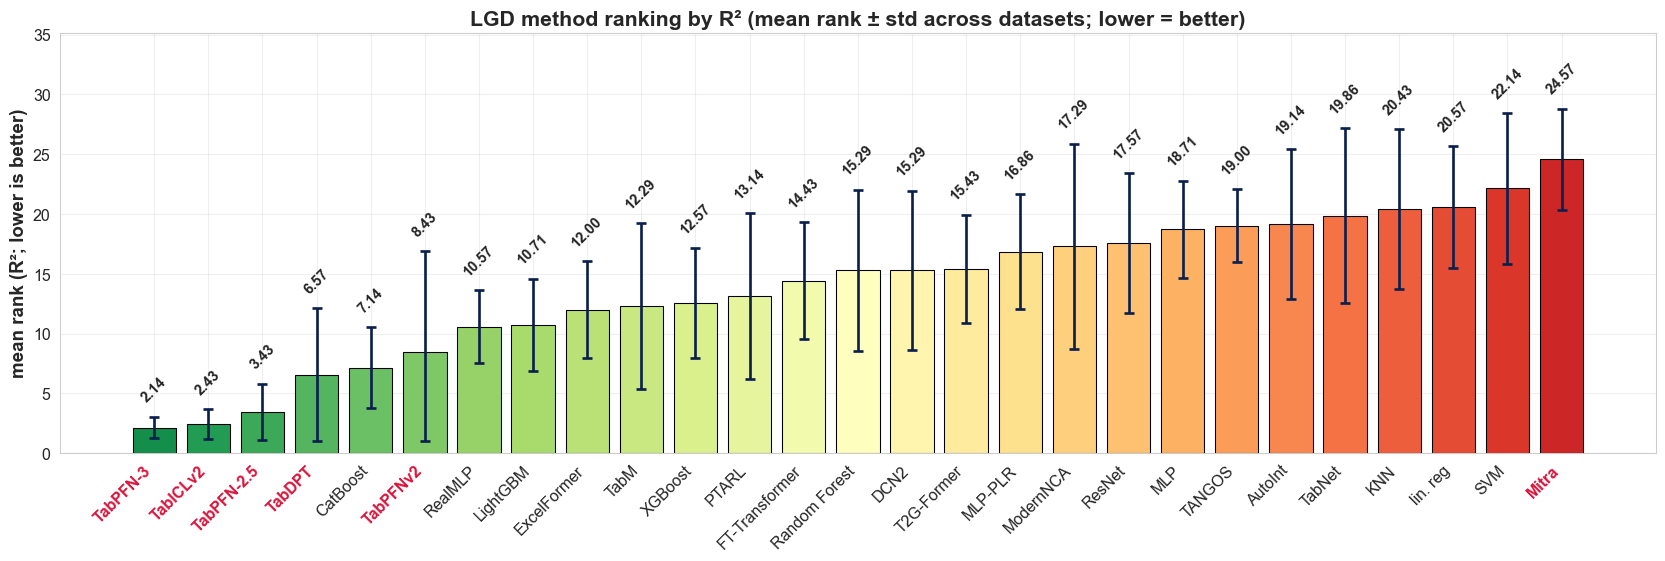

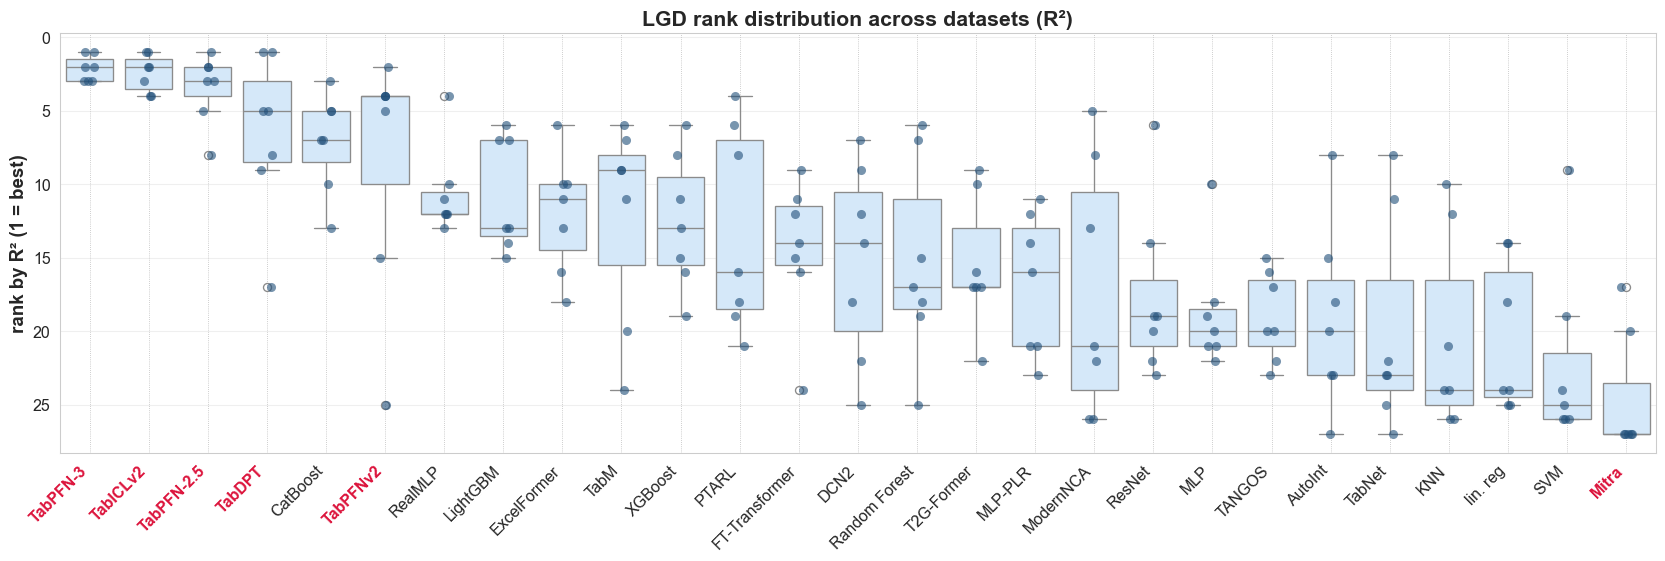

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_rank_box_r2.pdf')

In [4]:
rank_heatmap(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## 3. Pearson correlation

Linear association between predicted and realised LGD (higher is better). Matrix · bar · box.

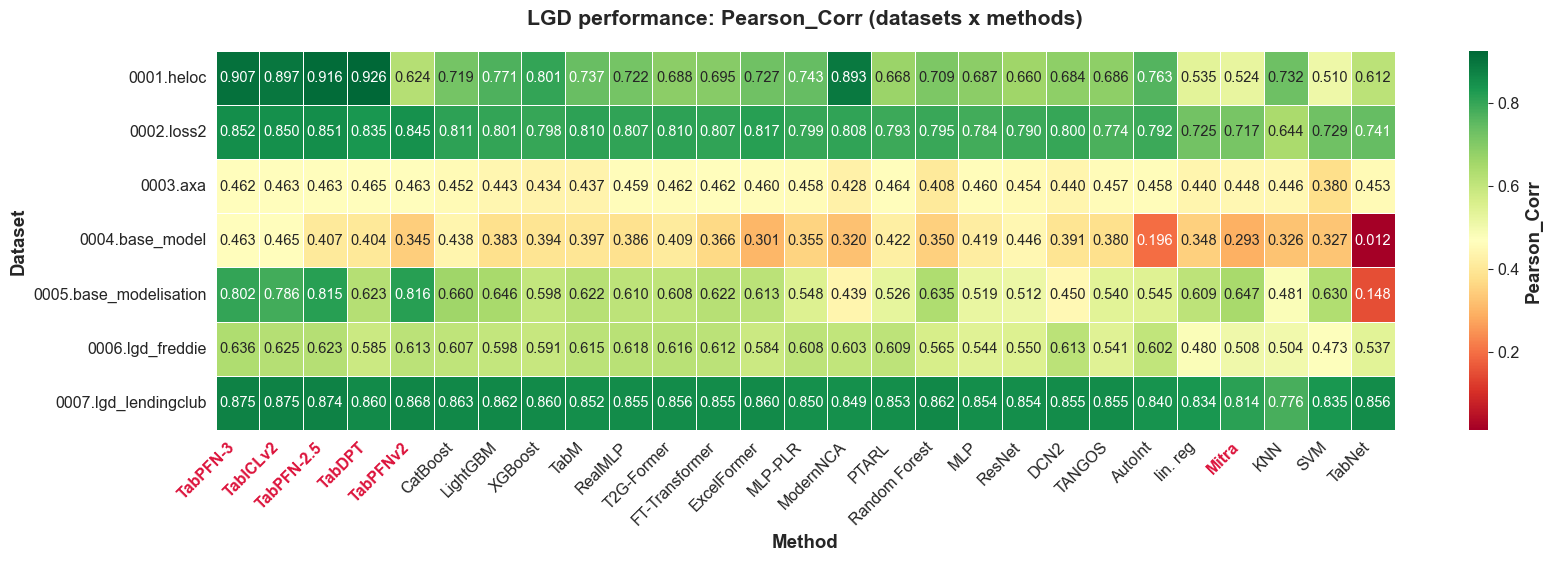

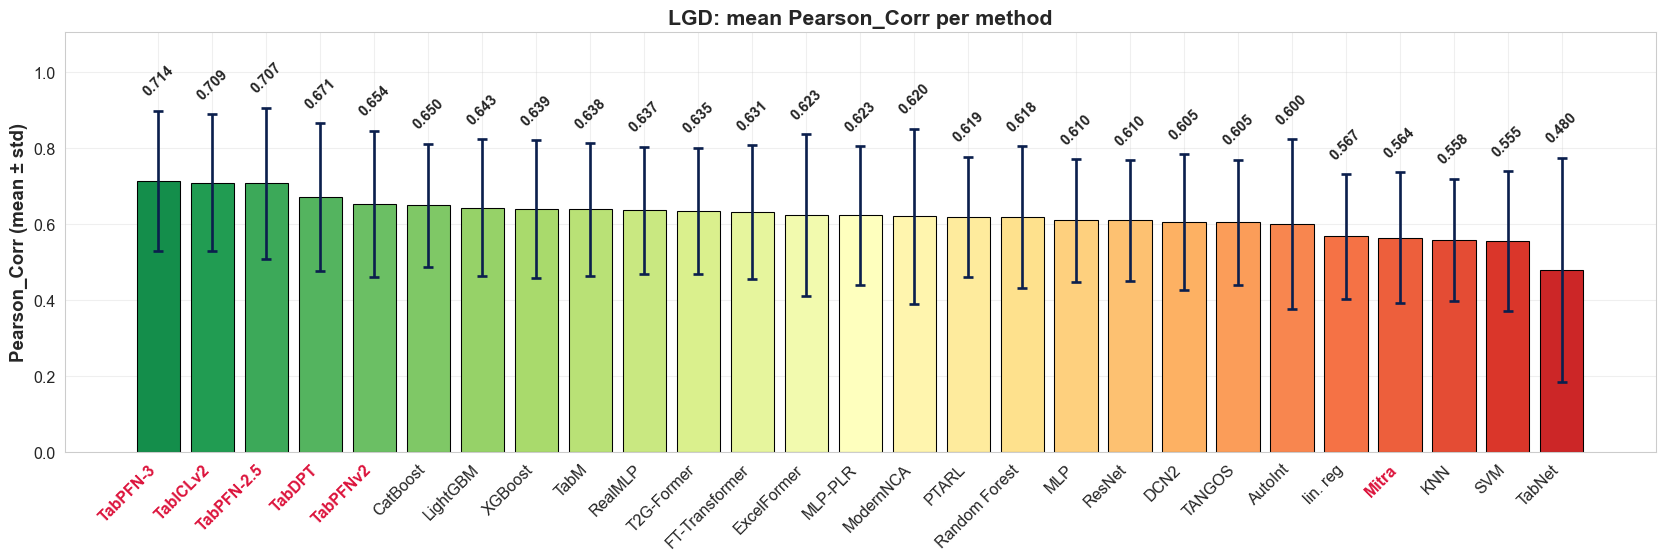

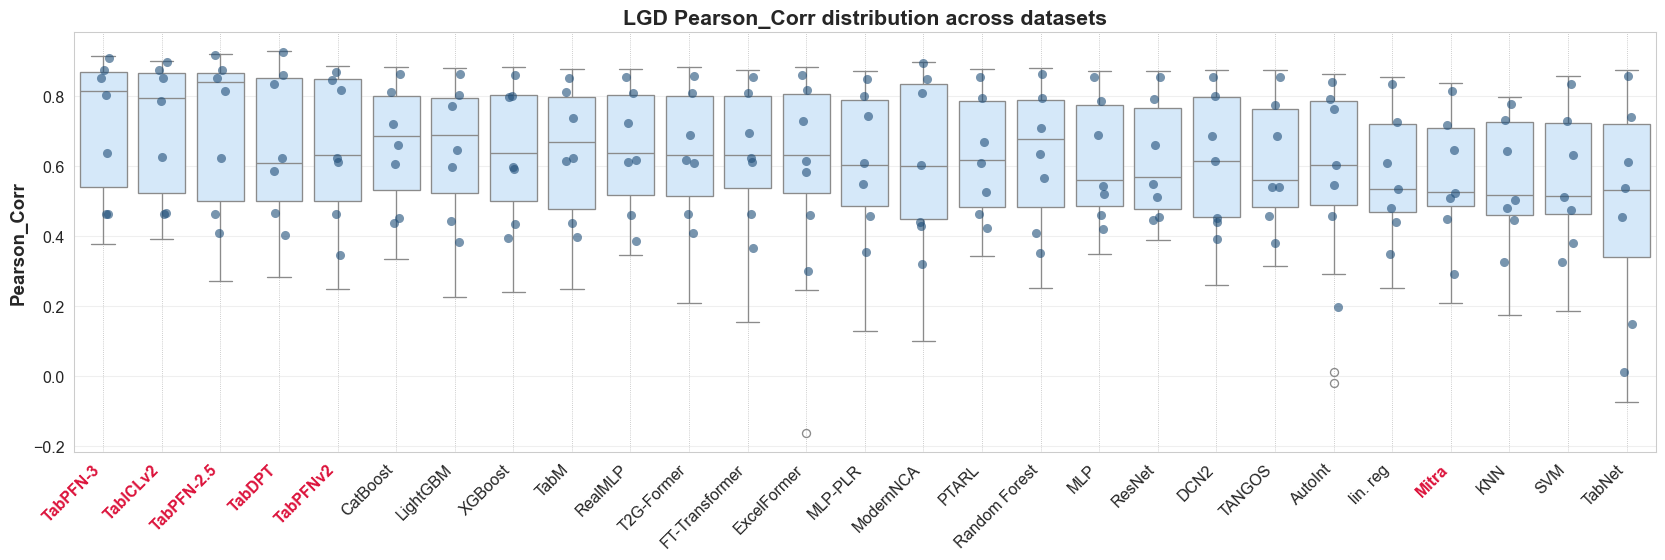

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_pearson_corr.pdf')

In [5]:
performance_heatmap(df, 'Pearson_Corr', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'Pearson_Corr', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'Pearson_Corr', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)

## 4. Effect of HPO on R²

Foundation models are 0 by design (their HPO run copies NO_HPO).

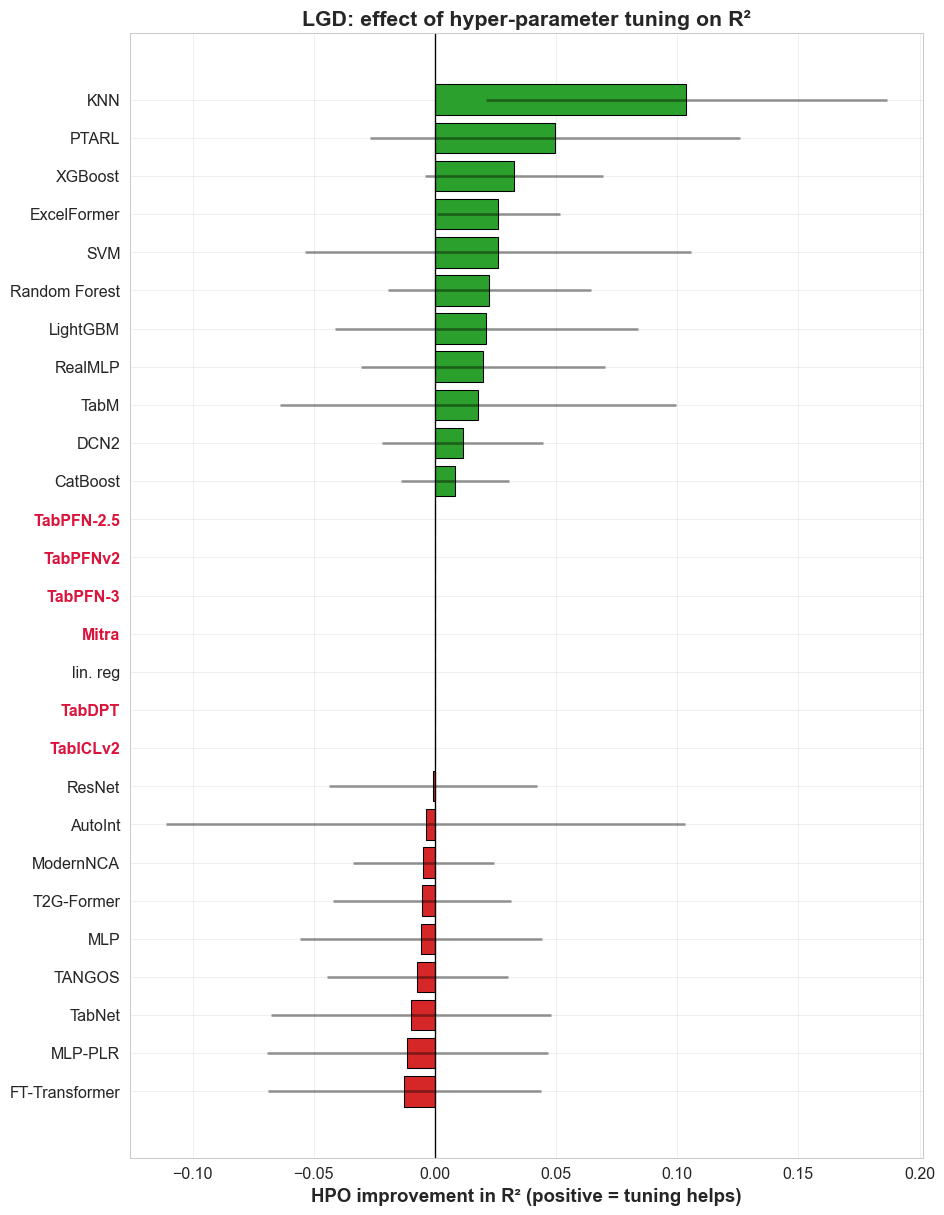

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_hpo_effect_r2.pdf')

In [6]:
hpo_improvement_bars(df_both, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## 5. Time analysis — train + predict + HPO

Tunable methods' training time × `n_trials` (the hyperparameter search) plus fit + predict; the boxplot shows the raw per-fold spread and the scatter the R²-vs-cost frontier (**median** time on x, **mean** R² on y).

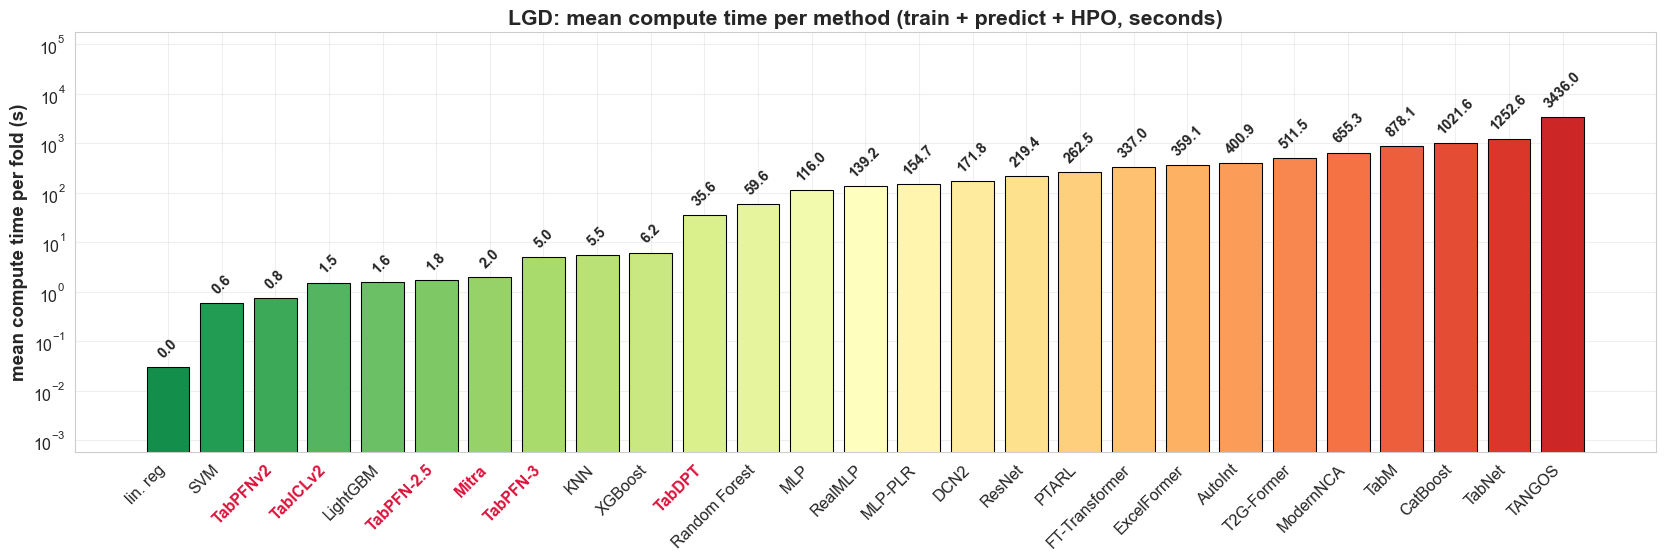

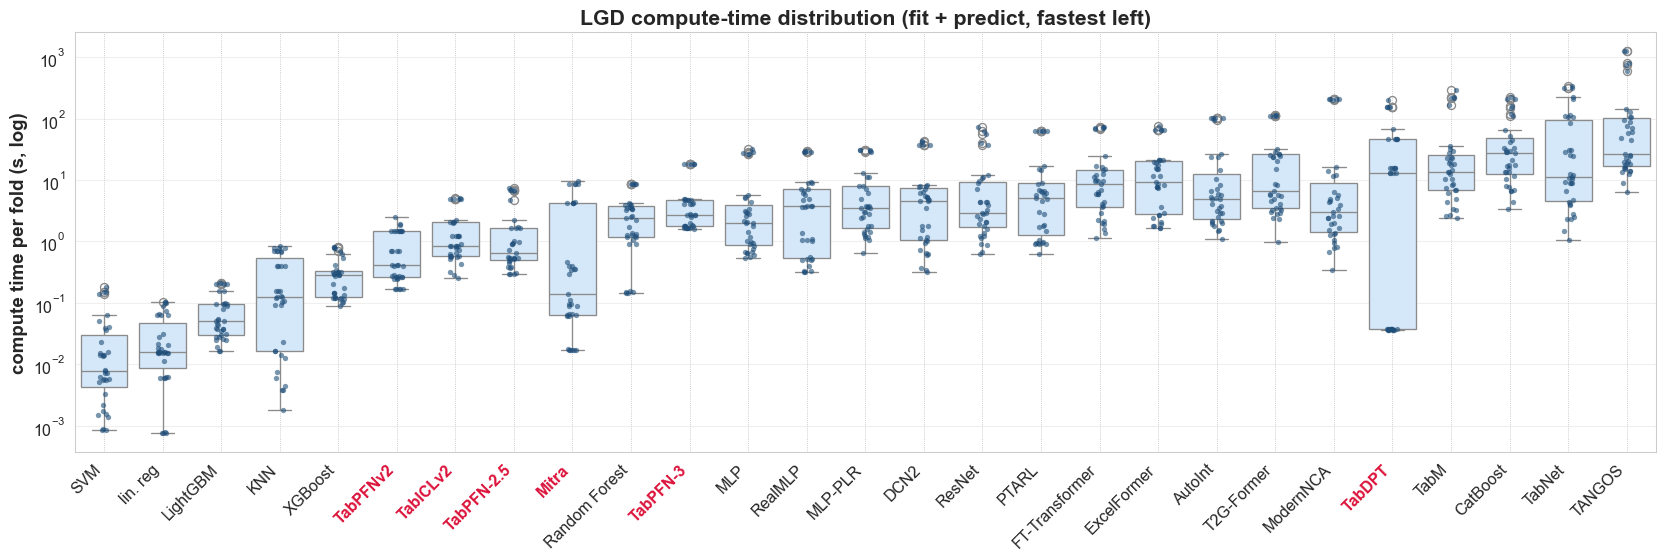

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_compute_time.pdf')

In [7]:
compute_time_bars(df, task_name='LGD', hpo_methods=HPO_METHODS, n_trials=20, out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='LGD', out_dir=FIGURES_DIR)

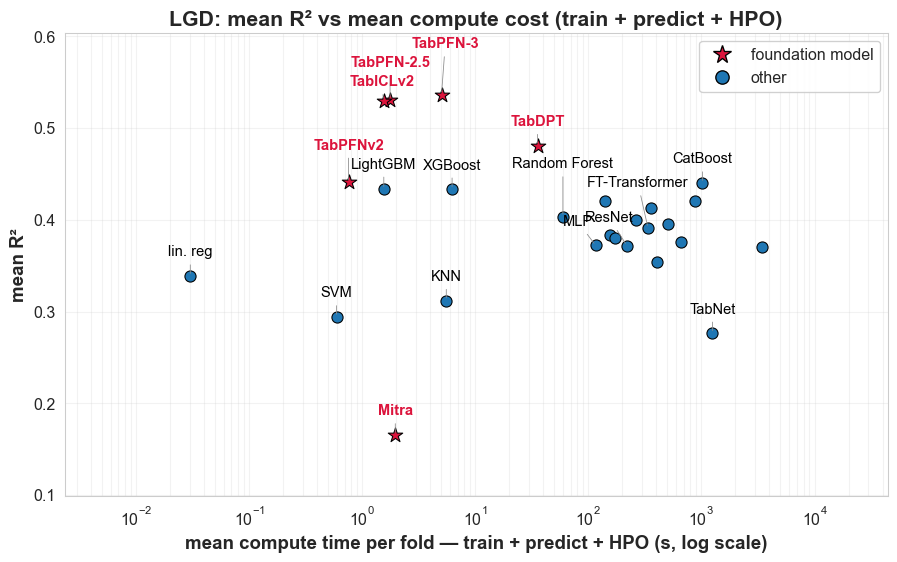

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_cost_quality_r2.pdf')

In [8]:
runtime_performance_scatter(df, 'R2', task_name='LGD', hpo_methods=HPO_METHODS, n_trials=20, out_dir=FIGURES_DIR)

## 6. TabPFN v3 vs the baselines — head-to-head

The foundation model against the two reference baselines in turn: **CatBoost** (strongest classical learner) and **lin. reg** (the regulatory / industry-standard credit baseline). For each, first the **relative R² improvement** per dataset against dataset size, with an OLS trend — does the edge grow on small data? Green = TabPFN v3 wins; the dashed line is equal performance. Then a per-dataset absolute R² scatter with the **y = x** equal-performance diagonal.

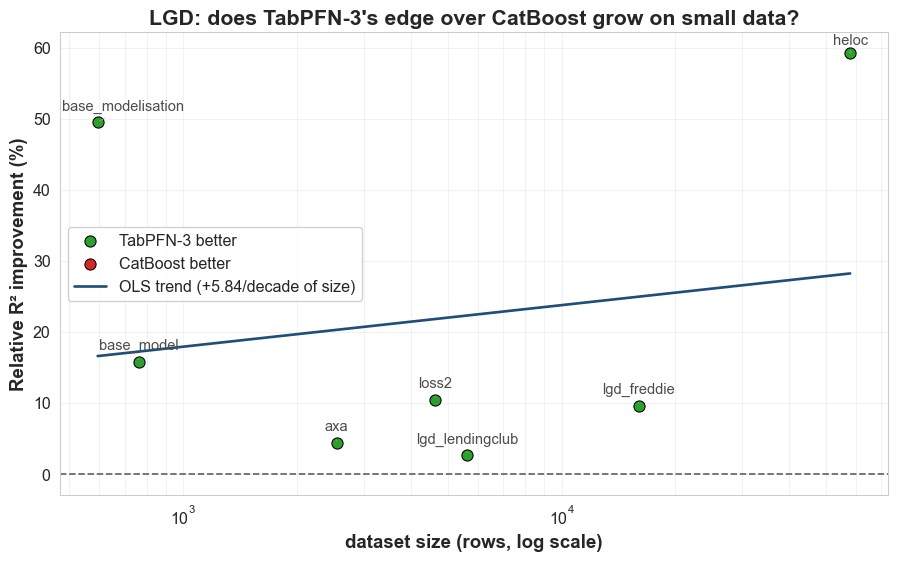

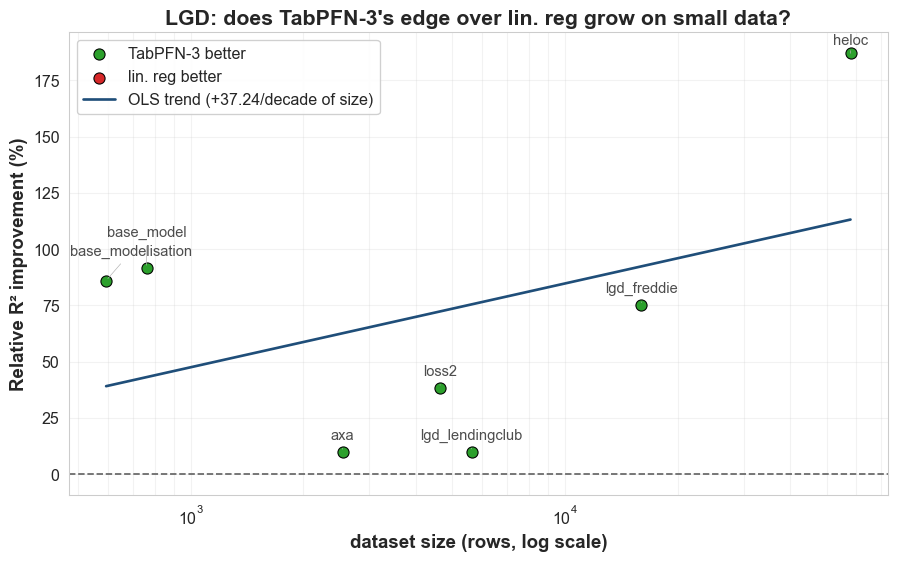

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_tabpfn_v3_vs_LinearRegression_sizetrend_r2.pdf')

In [9]:
foundation_vs_baseline_size_trend(df, metric='R2', task='lgd', task_name='LGD', relative=True, higher_is_better=True, out_dir=FIGURES_DIR)
foundation_vs_baseline_size_trend(df, metric='R2', task='lgd', task_name='LGD', base_method='LinearRegression', relative=True, higher_is_better=True, out_dir=FIGURES_DIR)

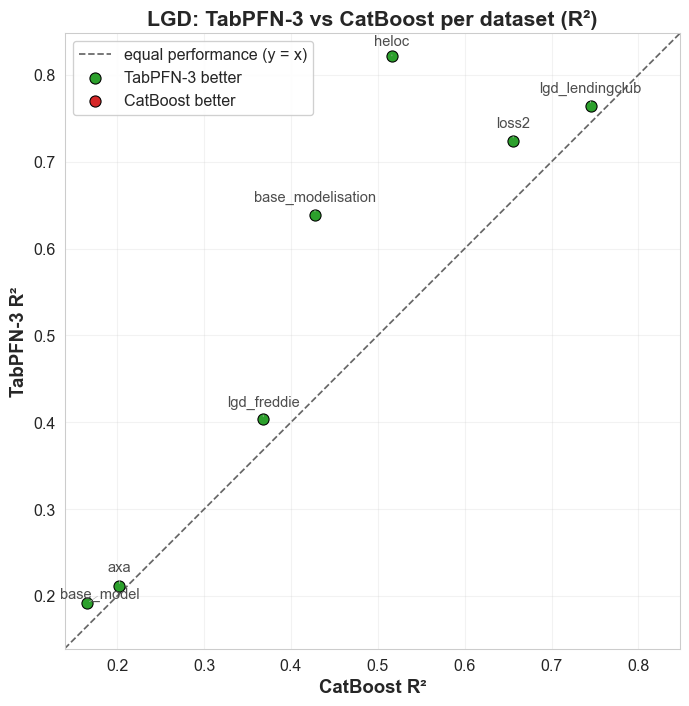

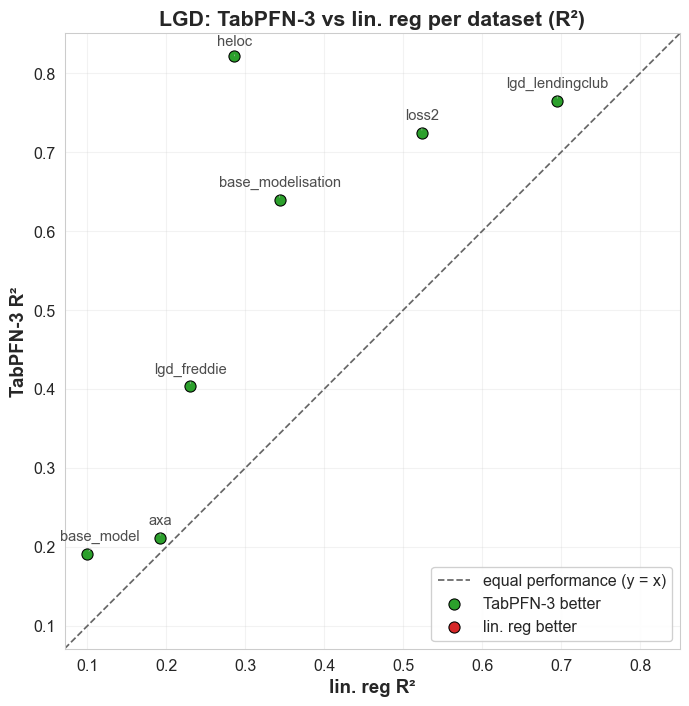

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_tabpfn_v3_vs_LinearRegression_scatter_r2.pdf')

In [10]:
foundation_vs_baseline_scatter(df, metric='R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
foundation_vs_baseline_scatter(df, metric='R2', base_method='LinearRegression', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)

## 7. Prediction calibration and systematic bias

Comparison restricted to TabPFN-3, TabICLv2, CatBoost, and linear regression. Positive observed-minus-predicted values indicate underprediction.

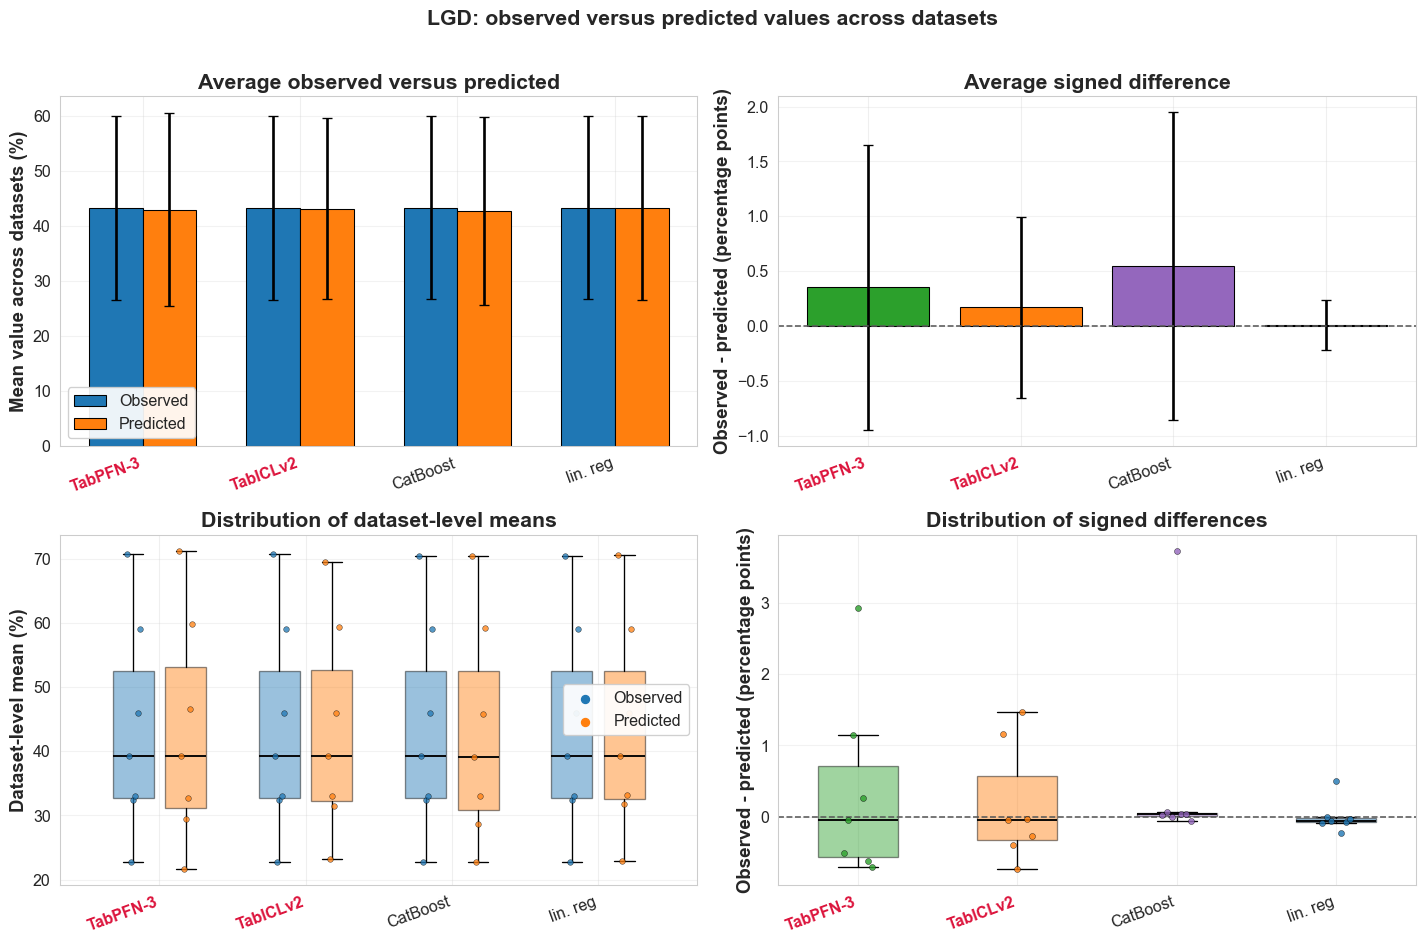

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_selected_calibration_summary.pdf')

In [11]:
lgd_calibration_methods = ('tabpfn_v3', 'tabicl_v2', 'catboost', 'LinearRegression')
lgd_calibration = calibration_bias_table(
    df, results_root=RESULTS_ROOT, task='lgd', methods=lgd_calibration_methods
)
selected_method_calibration_summary(
    lgd_calibration, task='lgd', methods=lgd_calibration_methods,
    task_name='LGD', out_dir=FIGURES_DIR
)

## 8. Summary

In [12]:
lgd_summary_text(df, task_name='Experiment 1 — LGD')

Experiment 1 — LGD — mean of every metric per method   (datasets: 7, methods: 27)
                      R²    RMSE     MAE  Spearman_Corr  Pearson_Corr     MSE   MedAE  MaxError  Explained_Variance         MAPE  MAPE_n_zeros_excluded  MAPE_pct_zeros_excluded  time_s (mean)
method                                                                                                                                                                                         
tabpfn_v3         0.5366  0.2234  0.1551         0.6686        0.7139  0.0555  0.1022    0.8898              0.5393   57100.7838               426.1714                  10.0321         5.0355
tabpfn_v2_5       0.5307  0.2235  0.1533         0.6619        0.7071  0.0560  0.0991    0.8906              0.5357   56463.0109               426.1714                  10.0321         1.7667
tabicl_v2         0.5298  0.2263  0.1608         0.6632        0.7088  0.0565  0.1108    0.8862              0.5318   63627.2310               426.171

'Experiment 1 — LGD — mean of every metric per method   (datasets: 7, methods: 27)\n=================================================================================\n                      R²    RMSE     MAE  Spearman_Corr  Pearson_Corr     MSE   MedAE  MaxError  Explained_Variance         MAPE  MAPE_n_zeros_excluded  MAPE_pct_zeros_excluded  time_s (mean)\nmethod                                                                                                                                                                                         \ntabpfn_v3         0.5366  0.2234  0.1551         0.6686        0.7139  0.0555  0.1022    0.8898              0.5393   57100.7838               426.1714                  10.0321         5.0355\ntabpfn_v2_5       0.5307  0.2235  0.1533         0.6619        0.7071  0.0560  0.0991    0.8906              0.5357   56463.0109               426.1714                  10.0321         1.7667\ntabicl_v2         0.5298  0.2263  0.1608         0.6632      